In [16]:
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer, AdamW
from datasets import load_dataset
from torch.utils.data import DataLoader, Subset, Dataset
from tqdm.auto import tqdm
import numpy as np
import random
import matplotlib.pyplot as plt
import ollama
import re

In [17]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

In [18]:
model_name = "distilbert-base-uncased"
num_labels = 2
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
tokenizer = AutoTokenizer.from_pretrained(model_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
 

In [19]:

train_dataset = load_dataset("glue", "sst2", split="train")
val_dataset = load_dataset("glue", "sst2", split="validation")

In [20]:
def collate_fn(batch):
    texts = [item["sentence"] for item in batch]
    labels = [item["label"] for item in batch]
    tokenized_inputs = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")
    tokenized_inputs["labels"] = torch.tensor(labels)
    return tokenized_inputs

In [21]:
def get_llm_augmented_samples(samples):
    prompt = """Here are 25 sentences with their associated sentiment labels (0 for negative, 1 for positive):\n"""
    for s in samples:
        prompt += f"- {s['sentence']} (Label: {s['label']})\n"
    prompt += "\nGenerate 5 new sentence examples that are similar in style and sentiment distribution. Format them as: <sentence> (Label: <0 or 1>)"

    response = ollama.chat(
        model='deepseek-r1',
        messages=[{'role': 'user', 'content': prompt}]
    )
    lines = response['message']['content'].strip().split('\n')
    results = []
    for line in lines:
        match = re.match(r"^(.*)\s+\(Label:\s*(\d)\)$", line.strip())
        if match:
            sentence, label = match.groups()
            results.append({"sentence": sentence.strip(), "label": int(label)})
    return results


In [22]:
class LLMGeneratedDataset(Dataset):
    def __init__(self, examples):
        self.examples = examples

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        return self.examples[idx]

In [23]:
initial_label_size = 50
acquisition_size = 50
max_iterations = 10

In [24]:
all_indices = list(range(len(train_dataset)))
random.shuffle(all_indices)
labeled_indices = all_indices[:initial_label_size]
unlabeled_indices = all_indices[initial_label_size:]

In [25]:
labeled_sizes = []
val_accuracies = []

In [26]:
for iteration in range(max_iterations):
    print(f"\n=== Active Learning Iteration {iteration+1} ===")

    labeled_subset = Subset(train_dataset, labeled_indices)
    labeled_loader = DataLoader(labeled_subset, batch_size=16, shuffle=True, collate_fn=collate_fn)
    optimizer = AdamW(model.parameters(), lr=2e-5)
    model.train()
    for epoch in range(5):
        for batch in tqdm(labeled_loader, desc=f"Training Epoch {epoch+1}"):
            optimizer.zero_grad()
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            optimizer.step()

    val_loader = DataLoader(val_dataset, batch_size=32, collate_fn=collate_fn)
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Evaluating"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"Validation Accuracy: {accuracy*100:.2f}%")

    labeled_sizes.append(len(labeled_indices))
    val_accuracies.append(accuracy)

    if len(unlabeled_indices) == 0:
        break

    acquisition_count = min(acquisition_size, len(unlabeled_indices))
    new_indices = random.sample(unlabeled_indices, acquisition_count)
    labeled_indices.extend(new_indices)
    unlabeled_indices = list(set(unlabeled_indices) - set(new_indices))
    print(f"Total labeled samples after acquisition: {len(labeled_indices)}")


=== Active Learning Iteration 1 ===


Training Epoch 1:   0%|          | 0/4 [00:00<?, ?it/s]

Training Epoch 2:   0%|          | 0/4 [00:00<?, ?it/s]

Training Epoch 3:   0%|          | 0/4 [00:00<?, ?it/s]

Training Epoch 4:   0%|          | 0/4 [00:00<?, ?it/s]

...

Training Epoch 3:   0%|          | 0/32 [00:00<?, ?it/s]

Training Epoch 4:   0%|          | 0/32 [00:00<?, ?it/s]

Training Epoch 5:   0%|          | 0/32 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/28 [00:00<?, ?it/s]

Validation Accuracy: 80.39%
Total labeled samples after acquisition: 550


In [28]:
def get_most_uncertain_samples(model, tokenizer, dataset, num_samples=25):
    """
    Select samples from the dataset where the model is most uncertain.
    Uncertainty is measured via entropy of the predicted probabilities.
    """
    model.eval()
    uncertainties = []
    texts = []

    val_loader = DataLoader(dataset, batch_size=32, collate_fn=collate_fn)
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            outputs = model(input_ids, attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=-1)
            entropy = -torch.sum(probs * torch.log(probs + 1e-12), dim=1)  # Shape: (batch_size,)
            uncertainties.extend(entropy.cpu().numpy())
            texts.extend(batch["input_ids"])  # token ids

    # Map token ids back to raw sentences
    decoded_texts = [tokenizer.decode(ids, skip_special_tokens=True) for ids in texts]
    entropy_indices = np.argsort(uncertainties)[-num_samples:][::-1]  # Most uncertain at top

    selected_samples = []
    for idx in entropy_indices:
        selected_samples.append({
            "sentence": decoded_texts[idx],
            "label": random.choice([0, 1])  # placeholder label just for prompt format
        })
    return selected_samples


In [29]:
# LLM-based augmentation
print("\n=== Starting LLM-based Data Augmentation ===")
llm_accuracies = []
for epoch in range(10):
    print(f"\n--- LLM Augmentation Epoch {epoch+1} ---")

    # Use uncertain samples for prompting
    uncertain_samples = get_most_uncertain_samples(model, tokenizer, val_dataset, num_samples=25)
    generated_examples = get_llm_augmented_samples(uncertain_samples)

    if not generated_examples:
        print("Warning: No LLM samples generated. Skipping this epoch.")
        continue

    # Print generated examples
    print("\nGenerated Examples:")
    for i, ex in enumerate(generated_examples):
        print(f"{i+1}. \"{ex['sentence']}\" (Label: {ex['label']})")

    generated_dataset = LLMGeneratedDataset(generated_examples)
    if len(generated_dataset) == 0:
        print("Warning: LLMGeneratedDataset is empty. Skipping this epoch.")
        continue

    gen_loader = DataLoader(generated_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)

    model.train()
    for batch in gen_loader:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)
            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"\nValidation Accuracy after LLM Epoch {epoch+1}: {acc*100:.2f}%")
    llm_accuracies.append(acc)



=== Starting LLM-based Data Augmentation ===

--- LLM Augmentation Epoch 1 ---

Generated Examples:
1. "A) The intricate design of the modern skyscraper is nothing short of extraordinary." (Label: 1)
2. "B) The restoration effort for the ancient artifact failed to capture its original essence, leaving it feeling a little disheartening." (Label: 0)
3. "C) The athlete's grueling training session was both intense and amusing, leaving everyone in awe." (Label: 1)
4. "D) The relentless downpour left everything looking like a scene from a storm movie, causing more trouble than weather." (Label: 0)
5. "E) The masterful painting on the wall not only beautified the room but also left the guests in awe of its artistry." (Label: 1)

Validation Accuracy after LLM Epoch 1: 80.28%

--- LLM Augmentation Epoch 2 ---

Generated Examples:
1. "1. **Book Review**: "The novel is a compelling read, weaving intricate plots with rich character development, but falters when it comes to pacing, leaving the rea

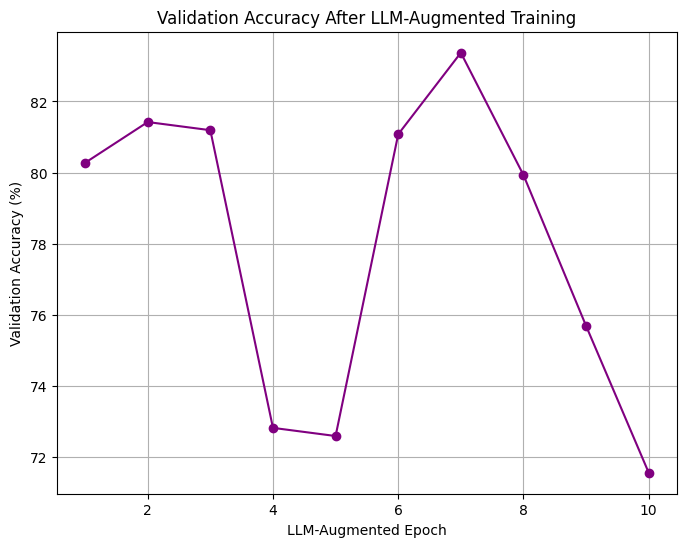

In [30]:
plt.figure(figsize=(8,6))
plt.plot(range(1, 11), [a*100 for a in llm_accuracies], marker='o', color='purple')
plt.xlabel("LLM-Augmented Epoch")
plt.ylabel("Validation Accuracy (%)")
plt.title("Validation Accuracy After LLM-Augmented Training")
plt.grid(True)
plt.show()
